In [1]:
"""
Multi-timescale demonstration for the exp-OU driven role-reversal model.

The prey attack rate is G(U) = g_min + Delta*exp(U), Delta = g_bar - g_min,
with U an Ornstein-Uhlenbeck process of mean-reversion rate alpha.  We compare
three correlation rates spanning the resonance:

    alpha = 10        (fast noise, tau_OU = 0.1, much faster than T_0)
    alpha = omega_0   (resonance, tau_OU = 1/omega_0 = T_0/(2*pi))
    alpha = 0.02      (slow noise, tau_OU = 50, comparable to T_0)

To isolate the timescale effect from the amplitude effect we fix the
stationary variance of the latent driver, v = sigma_U^2/(2*alpha) = 1.25e-3,
across all three runs, so that sigma_U = sqrt(2*alpha*v).  With Delta fixed
this also fixes std(G) = Delta*sqrt(e^v (e^v - 1)) ~ 0.0106.

Three columns of analysis:
  (1) Time series of G(t) and x(t) over a window of ~5 T_0
  (2) Power spectrum of x(t)
  (3) Autocorrelation functions of G(t), x(t), and y_2(t)

The deterministic timescales are highlighted: tau_fast ~ 0.41 (fast mode of
J_0) and T_0 = 2*pi/omega_0 ~ 47.3 (slow oscillation).
"""

%matplotlib inline

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.signal import welch

# sde.py re-exports Params, E_star, g_hopf and jacobian: it uses model.py if
# that module is importable, and equivalent built-in definitions otherwise.
from sde import (Params, E_star, g_hopf, jacobian,
                 OUNoise, simulate_exp_ou_sde, g_min_default, DT_DEFAULT)

In [2]:
p = Params(s=0.2)
g1 = g_hopf(p)

# Deterministic intrinsic timescales at the Hopf
eq_h = E_star(p.with_(g=g1))
J0_h = jacobian(eq_h, p.with_(g=g1))
eigs_h = np.linalg.eigvals(J0_h)
omega_0 = float(np.max(np.abs(eigs_h.imag)))
B1_h = float(-np.min(eigs_h.real))   # fast eigenvalue magnitude
T_0 = 2*np.pi/omega_0
tau_fast = 1/B1_h
print("Deterministic timescales at Hopf:")
print(f"  omega_0 = {omega_0:.4f},   T_0 = 2*pi/omega_0 = {T_0:.2f}")
print(f"  B_1     = {B1_h:.4f},      tau_fast = 1/B_1 = {tau_fast:.3f}")
print(f"  Ratio T_0 / tau_fast = {T_0/tau_fast:.1f}\n")

# Operating point and exp-OU configuration
g_bar = 0.45                       # just above Hopf, where E* is stable
g_min = g_min_default(p)           # = s*k/b, the lower barrier of the support
VARIANCE = 1.25e-3                 # v = sigma_U^2/(2 alpha), fixed across alpha
alpha_cases = [10.0, omega_0, 0.02]
labels = [r"fast noise  ($\tau_{\rm OU} \ll T_0$)",
          r"resonance  ($\tau_{\rm OU} = T_0/(2\pi)$)",
          r"slow noise  ($\tau_{\rm OU} \sim T_0$)"]

# sigma_U = sqrt(2 alpha v), so that v is the same in every run
ous = [OUNoise.from_var_u(g_bar=g_bar, v=VARIANCE, alpha=a, g_min=g_min)
       for a in alpha_cases]

print(f"exp-OU driver:  g_min = {g_min:.4f},  g_bar = {g_bar},  "
      f"Delta = {g_bar - g_min:.4f},  fixed v = {VARIANCE:g}  "
      f"(std(U) = {np.sqrt(VARIANCE):.5f})")
for a, ou in zip(alpha_cases, ous):
    print(f"  alpha = {a:7.4f}   sigma_U = {ou.sigma:.5f}   "
          f"v = {ou.stationary_var_U:.5f}   "
          f"E[G] = {ou.stationary_mean_G(p):.5f}   "
          f"std(G) = {ou.stationary_std_G(p):.5f}")
print()

# Simulation parameters - long enough for good autocorrelations
T_END   = 4000.0
DT      = DT_DEFAULT      # 1e-3
BURN    = 500.0
STORE_EVERY = 20          # effective sampling interval DT*STORE_EVERY = 0.02

eq = E_star(p.with_(g=g_bar))
ic = tuple(eq * np.array([1.05, 0.95, 0.95]))
print(f"E*(g_bar) = {eq},  initial condition = {ic}")
print(f"steps per run = {int(T_END/DT):,},  stored points = {int(T_END/DT/STORE_EVERY):,}")

Deterministic timescales at Hopf:
  omega_0 = 0.1329,   T_0 = 2*pi/omega_0 = 47.28
  B_1     = 2.4660,      tau_fast = 1/B_1 = 0.406
  Ratio T_0 / tau_fast = 116.6

exp-OU driver:  g_min = 0.1500,  g_bar = 0.45,  Delta = 0.3000,  fixed v = 0.00125  (std(U) = 0.03536)
  alpha = 10.0000   sigma_U = 0.15811   v = 0.00125   E[G] = 0.45019   std(G) = 0.01062
  alpha =  0.1329   sigma_U = 0.01823   v = 0.00125   E[G] = 0.45019   std(G) = 0.01062
  alpha =  0.0200   sigma_U = 0.00707   v = 0.00125   E[G] = 0.45019   std(G) = 0.01062

E*(g_bar) = [4.  0.6 1.2],  initial condition = (np.float64(4.200000000000003), np.float64(0.5699999999999998), np.float64(1.1399999999999997))
steps per run = 4,000,000,  stored points = 200,000


In [3]:
# Run simulations  (~30 s per trajectory at dt = 1e-3)
import time
print("Running three SDE trajectories ...")
sims = []
for a, ou in zip(alpha_cases, ous):
    t0 = time.time()
    t, X = simulate_exp_ou_sde(p, ou, t_end=T_END, dt=DT, ic=ic, seed=42,
                               store_every=STORE_EVERY)
    mask = t >= BURN
    sims.append({"alpha": a, "sigma": ou.sigma, "ou": ou,
                 "t": t[mask], "X": X[mask]})
    G = X[mask][:, 3]
    print(f"  alpha = {a:7.4f}, sigma_U = {ou.sigma:.5f}  (tau_OU = {1/a:7.3f})"
          f"   empirical mean(G) = {G.mean():.4f}, std(G) = {G.std():.4f},"
          f"   min(G) = {G.min():.4f} > g_min = {g_min:.2f}"
          f"   [{time.time()-t0:.1f} s]")
print("done.\n")

Running three SDE trajectories ...
  alpha = 10.0000, sigma_U = 0.15811  (tau_OU =   0.100)   empirical mean(G) = 0.4503, std(G) = 0.0106,   min(G) = 0.3966 > g_min = 0.15   [35.6 s]
  alpha =  0.1329, sigma_U = 0.01823  (tau_OU =   7.526)   empirical mean(G) = 0.4514, std(G) = 0.0105,   min(G) = 0.4159 > g_min = 0.15   [35.6 s]
  alpha =  0.0200, sigma_U = 0.00707  (tau_OU =  50.000)   empirical mean(G) = 0.4532, std(G) = 0.0105,   min(G) = 0.4232 > g_min = 0.15   [35.5 s]
done.



Saved timescales_demo.{png,pdf}


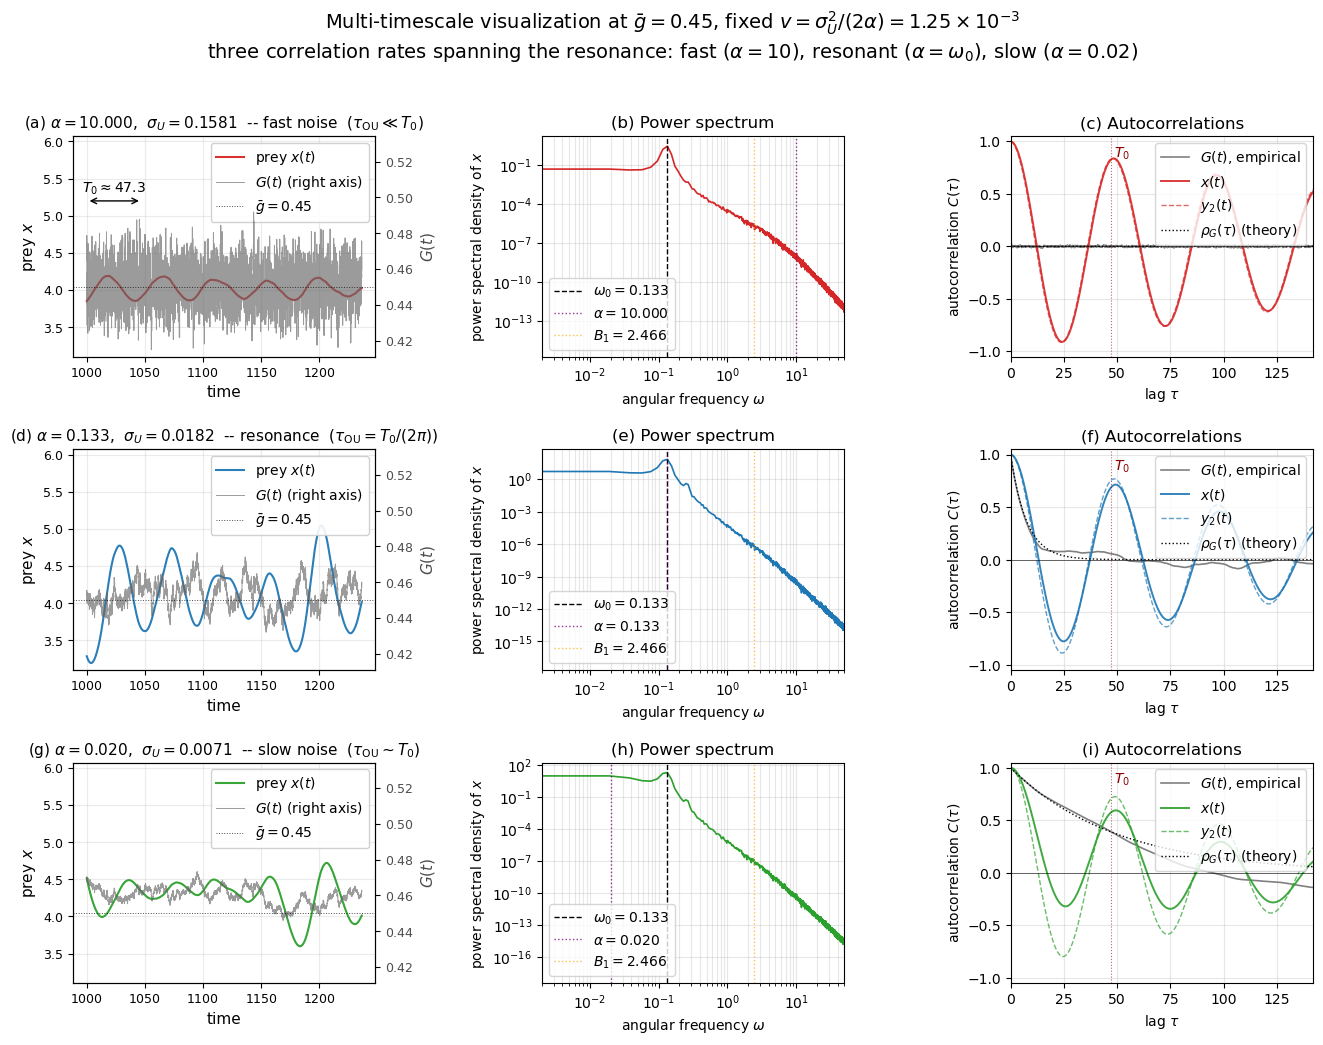

In [5]:
# ============================================================
# Build figure
# ============================================================
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(3, 3, hspace=0.42, wspace=0.55)

colors_row = ["#d62728", "#1f77b4", "#2ca02c"]

# Helper for autocorrelation
def autocorr(y, max_lag=None):
    y = y - y.mean()
    n = len(y)
    if max_lag is None:
        max_lag = n // 2
    out = np.zeros(max_lag + 1)
    var = np.dot(y, y) / n
    for k in range(max_lag + 1):
        out[k] = np.dot(y[:n-k], y[k:]) / (n - k) / var
    return out

for row, (sim, label, col) in enumerate(zip(sims, labels, colors_row)):
    t = sim["t"]
    X = sim["X"]
    a = sim["alpha"]; s = sim["sigma"]; ou = sim["ou"]
    Xp = X[:, 0]    # prey
    Y2p = X[:, 2]   # adult predator
    Gp = X[:, 3]    # exp-OU forcing

    if row == 0:
        # ------- pre-compute a common (x, G) y-range across all three rows -------
        prey_all = []
        Gvals_all = []
        for sim_j in sims:
            t_j = sim_j["t"]; X_j = sim_j["X"]
            sel_j = (t_j >= 1000) & (t_j <= 1000 + 5*T_0)
            prey_all.append(X_j[sel_j, 0])
            Gvals_all.append(X_j[sel_j, 3])
        prey_all = np.concatenate(prey_all)
        Gvals_all = np.concatenate(Gvals_all)
        prey_lo, prey_hi = prey_all.min(), prey_all.max()
        prey_pad = 0.55 * (prey_hi - prey_lo)     # extra headroom for the legend
        PREY_YLIM = (prey_lo - 0.05 * (prey_hi - prey_lo),
                     prey_hi + prey_pad)
        G_lo, G_hi = Gvals_all.min(), Gvals_all.max()
        G_pad = 0.55 * (G_hi - G_lo)
        G_YLIM = (G_lo - 0.05 * (G_hi - G_lo), G_hi + G_pad)

    # ----------------- column 1: time series -----------------
    ax = fig.add_subplot(gs[row, 0])
    t_window_start = 1000
    t_window_end   = t_window_start + 5*T_0
    sel = (t >= t_window_start) & (t <= t_window_end)

    l_prey, = ax.plot(t[sel], Xp[sel], "-", color=col, lw=1.5, alpha=0.95,
                     label=r"prey $x(t)$")
    ax.set_xlabel("time", fontsize=11)
    ax.set_ylabel(r"prey $x$", fontsize=11)
    ax.set_ylim(*PREY_YLIM)
    ax.tick_params(labelsize=9)

    # Twin axis for G(t) in its own units
    ax_g = ax.twinx()
    l_G, = ax_g.plot(t[sel], Gp[sel], "-", color="0.4", lw=0.7, alpha=0.65,
                    label=r"$G(t)$ (right axis)")
    l_gbar = ax_g.axhline(g_bar, ls=":", color="black", lw=0.7, alpha=0.7,
                          label=rf"$\bar g = {g_bar}$")
    ax_g.set_ylabel(r"$G(t)$", color="0.3", fontsize=11)
    ax_g.tick_params(axis="y", labelcolor="0.3", labelsize=9)
    ax_g.set_ylim(*G_YLIM)

    # Annotate T_0 in the top row only.
    if row == 0:
        prey_top_frac = (prey_hi - PREY_YLIM[0]) / (PREY_YLIM[1] - PREY_YLIM[0])
        y_top = PREY_YLIM[0] + (prey_top_frac + 0.05) * (PREY_YLIM[1] - PREY_YLIM[0])
        ax.annotate("", xy=(t_window_start + T_0, y_top),
                    xytext=(t_window_start, y_top),
                    arrowprops=dict(arrowstyle="<->", color="black", lw=1.0))
        ax.text(t_window_start + T_0/2, y_top + 0.02*(PREY_YLIM[1]-PREY_YLIM[0]),
                r"$T_0 \approx 47.3$", ha="center", va="bottom", fontsize=10)
    ax.set_title(rf"({chr(97+3*row)}) $\alpha = {a:.3f}$,  $\sigma_U = {s:.4f}$  -- {label}",
                 fontsize=11)

    ax.legend([l_prey, l_G, l_gbar],
              [h.get_label() for h in [l_prey, l_G, l_gbar]],
              fontsize=10, loc="upper right", framealpha=0.9, ncol=1)
    ax.grid(alpha=0.25)

    # ----------------- column 2: power spectrum -----------------
    ax = fig.add_subplot(gs[row, 1])
    dt_eff = t[1] - t[0]
    fs = 1.0 / dt_eff
    nperseg = min(16384, len(Xp))
    f, P_x = welch(Xp - Xp.mean(), fs=fs, nperseg=nperseg, scaling="density")
    omega = 2*np.pi*f
    ax.loglog(omega, P_x, "-", color=col, lw=1.2)
    ax.axvline(omega_0, ls="--", color="black", lw=1.0,
               label=rf"$\omega_0 = {omega_0:.3f}$")
    ax.axvline(a, ls=":", color="purple", lw=1.0, alpha=0.8,
               label=rf"$\alpha = {a:.3f}$")
    ax.axvline(B1_h, ls=":", color="orange", lw=1.0, alpha=0.7,
               label=rf"$B_1 = {B1_h:.3f}$")
    ax.set_xlabel(r"angular frequency $\omega$")
    ax.set_ylabel(r"power spectral density of $x$")
    ax.set_xlim(2e-3, 50)
    ax.set_title(rf"({chr(97+3*row+1)}) Power spectrum")
    ax.legend(fontsize=10, loc="lower left")
    ax.grid(alpha=0.3, which="both")

    # ----------------- column 3: autocorrelations -----------------
    ax = fig.add_subplot(gs[row, 2])
    max_lag_steps = int(min(3 * T_0 / dt_eff, len(Gp) // 4))
    lags = np.arange(max_lag_steps + 1) * dt_eff
    C_G  = autocorr(Gp, max_lag=max_lag_steps)
    C_X  = autocorr(Xp, max_lag=max_lag_steps)
    C_Y2 = autocorr(Y2p, max_lag=max_lag_steps)

    ax.plot(lags, C_G, "-", color="gray", lw=1.2, label=r"$G(t)$, empirical")
    ax.plot(lags, C_X, "-", color=col, lw=1.4, alpha=0.9, label=r"$x(t)$")
    ax.plot(lags, C_Y2, "--", color=col, lw=1.0, alpha=0.7, label=r"$y_2(t)$")
    # Exact exp-OU autocorrelation of G:
    #   rho_G(tau) = (exp(v*exp(-alpha*tau)) - 1) / (exp(v) - 1) = exp(-alpha*tau) + O(v)
    v = ou.stationary_var_U
    rho_G = (np.exp(v*np.exp(-a*lags)) - 1.0) / (np.exp(v) - 1.0)
    ax.plot(lags, rho_G, ":", color="black", lw=1.0,
            label=r"$\rho_G(\tau)$ (theory)")
    ax.axhline(0, ls="-", color="k", lw=0.4)
    ax.axvline(T_0, ls=":", color="darkred", lw=0.8, alpha=0.6)
    ax.text(T_0+1, 0.85, r"$T_0$", color="darkred", fontsize=10)
    ax.set_xlabel(r"lag $\tau$")
    ax.set_ylabel(r"autocorrelation $C(\tau)$")
    ax.set_title(rf"({chr(97+3*row+2)}) Autocorrelations")
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 3*T_0)
    ax.set_ylim(-1.05, 1.05)

fig.suptitle(
    r"Multi-timescale visualization at $\bar g = 0.45$, fixed $v = \sigma_U^2/(2\alpha) = 1.25\times 10^{-3}$" "\n"
    r"three correlation rates "
    r"spanning the resonance: fast ($\alpha = 10$), resonant ($\alpha = \omega_0$), "
    r"slow ($\alpha = 0.02$)",
    fontsize=14, y=0.995)

plt.savefig("Figures/timescales_demo.png", dpi=130, bbox_inches="tight")
plt.savefig("Figures/timescales_demo.pdf", format="pdf", bbox_inches="tight")
print("Saved timescales_demo.{png,pdf}")
plt.show()